#Análisis de Recursos Humanos - [Empresa Confidencial]

Análisis exploratorio de una base de datos de 100 empleados usando Python (pandas y matplotlib) y Excel.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#lee el archivo CSV y lo convierte en un DataFrame (la versión pandas de una tabla Excel)
#df es el nombre que le damos a esa tabla — es convención usar df de "DataFrame"
df = pd.read_csv('employees.csv')
df.head()

,empleado_id,nombre,apellido,genero,fecha_nacimiento,fecha_ingreso,departamento,cargo,nivel_educativo,salario_mensual,desempeno,ciudad
0,E001,Carlos,Quispe,M,1985-03-12,2015-06-01,Ventas,Ejecutivo de Ventas,Universitario,3200,Bueno,Lima
1,E002,María,Flores,F,1990-07-24,2018-02-15,Recursos Humanos,Analista de RRHH,Universitario,2800,Excelente,Lima
2,E003,Jorge,Mamani,M,1982-11-05,2010-09-01,Operaciones,Supervisor,Técnico,2500,Regular,Arequipa
3,E004,Lucía,Torres,F,1995-01-30,2020-03-10,Tecnología,Desarrolladora,Universitario,4200,Excelente,Lima
4,E005,Roberto,Huanca,M,1988-06-18,2013-11-20,Finanzas,Contador,Universitario,3500,Bueno,Lima


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   empleado_id       100 non-null    object
 1   nombre            100 non-null    object
 2   apellido          100 non-null    object
 3   genero            100 non-null    object
 4   fecha_nacimiento  100 non-null    object
 5   fecha_ingreso     100 non-null    object
 6   departamento      100 non-null    object
 7   cargo             100 non-null    object
 8   nivel_educativo   100 non-null    object
 9   salario_mensual   100 non-null    int64 
 10  desempeno         100 non-null    object
 11  ciudad            100 non-null    object
dtypes: int64(1), object(11)
memory usage: 9.5+ KB


In [ ]:
df.describe()

,salario_mensual
count,100.000000
mean,4630.000000
std,2561.584894
min,1000.000000
25%,3000.000000
50%,3650.000000
75%,5225.000000
max,14000.000000


In [ ]:
#Convierte la columna fecha_ingreso de texto a formato fecha que python entiende.
df['fecha_ingreso'] = pd.to_datetime(df['fecha_ingreso'])
#Calcula la diferencia entre hoy y la fecha de ingreso en días, divide en 365.25(bisiestos) y convierte a entero.
df['anios_antiguedad'] = ((pd.Timestamp.today() - df['fecha_ingreso']).dt.days / 365.25).astype(int)
df['anios_antiguedad'].head()

,anios_antiguedad
0,11
1,8
2,15
3,6
4,12


##Análisis 1 - Salario Promedio por Departamento
¿Qué departamento paga mejor en la empresa?

In [ ]:
salario_depto = df.groupby('departamento')['salario_mensual'].mean().round(2).sort_values(ascending=False)
salario_depto
#sort_values(ascendig=False), ordena de mayor a menor


,salario_mensual
departamento,
Tecnología,5420.00
Finanzas,5011.76
Operaciones,4716.67
Ventas,4558.82
Marketing,4192.86
Recursos Humanos,3450.00


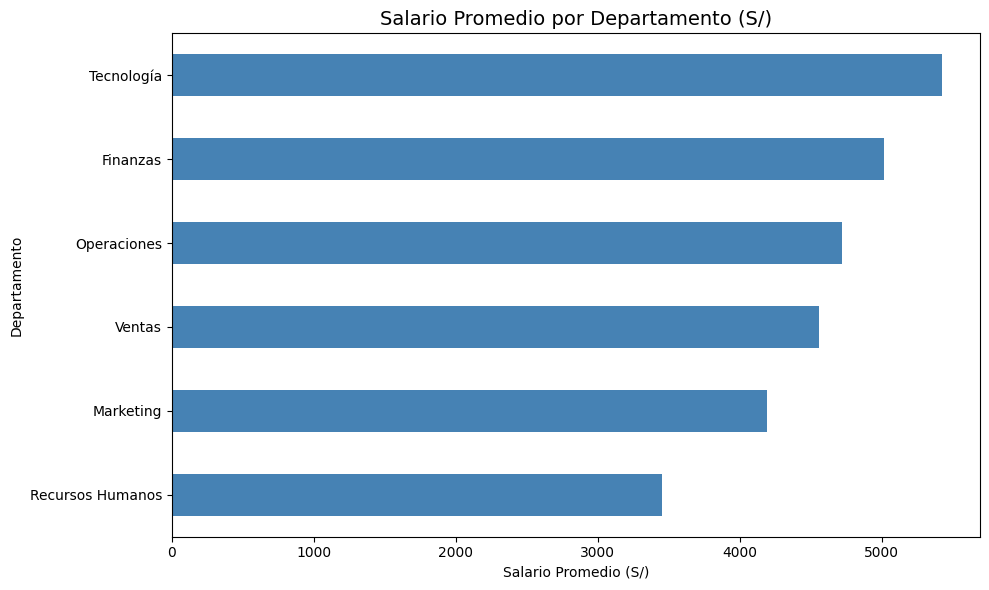

In [ ]:
plt.figure(figsize=(10,6))
salario_depto.sort_values().plot(kind='barh', color='steelblue')
plt.title('Salario Promedio por Departamento (S/)', fontsize=14)
plt.xlabel('Salario Promedio (S/)')
plt.ylabel('Departamento')
plt.tight_layout()
plt.show()

**Conclusión:** Tecnología lidera en salarios impulsado por la demanda del mercado, no por antigüedad. Recursos Humanos es el área menos remunerada a pesar de su rol estratégico.

##Análisis 2 - Distribución de empleados por género
¿Existe equilibrio de género en la empresa?

In [ ]:
empleado_gen = df.groupby('genero')['empleado_id'].count().sort_values(ascending=False)
empleado_gen
#agrupa por género y cuenta los IDs de empleado

,empleado_id
genero,
F,50
M,50


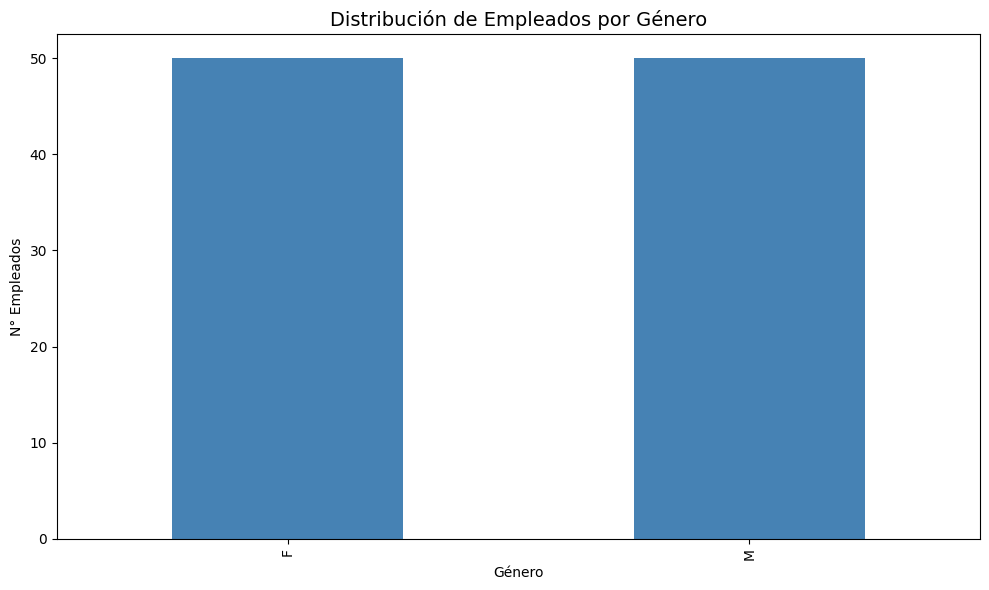

In [ ]:
plt.figure(figsize=(10,6))
empleado_gen.sort_values().plot(kind='bar', color='steelblue')
plt.title('Distribución de Empleados por Género', fontsize=14)
plt.xlabel('Género')
plt.ylabel('N° Empleados')
plt.tight_layout()
plt.show()

**Conclusión:** La empresa mantiene un equilibrio global de 50/50. Marketing tiene predominancia femenina y Operaciones, masculina, reflejando las tendencias del mercado laboral peruano.

##Análisis 3 - Salario por Nivel Educativo
¿Estudiar más garantiza ganar más?

In [ ]:
nivel_edu = df.groupby('nivel_educativo')['salario_mensual'].mean().round(2).sort_values()
nivel_edu

,salario_mensual
nivel_educativo,
Secundaria,1950.00
Técnico,2607.69
Universitario,3715.62
Posgrado,8923.81


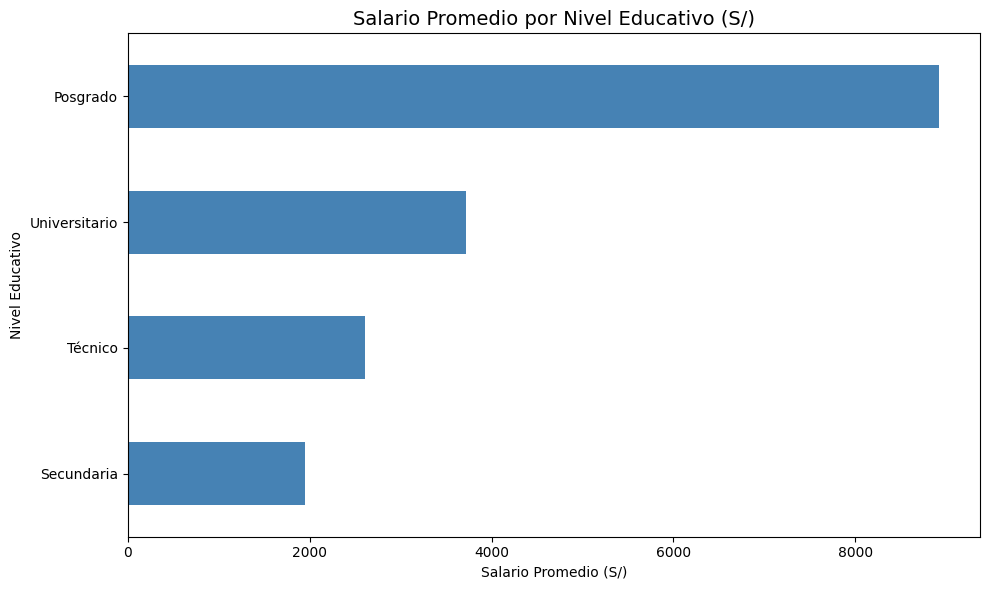

In [ ]:
plt.figure(figsize=(10,6))
nivel_edu.sort_values().plot(kind='barh', color='steelblue')
plt.title('Salario Promedio por Nivel Educativo (S/)', fontsize=14)
plt.xlabel('Salario Promedio (S/)')
plt.ylabel('Nivel Educativo')
plt.tight_layout()
plt.show()

**Conclusión:** A mayor nivel educativo, mayor salario — sin excepciones. El salto más significativo ocurre entre Universitario (S/ 3,715) y Posgrado (S/ 8,923), casi el doble.

##Análisis 4 - Antigüedad por Departamento
¿En qué áreas permanecen más tiempo los empleados?

In [ ]:
#"Del DataFrame, agrupa por departamento, toma la columna anios_antiguedad y calcula el promedio, ordena de mayor a menor"
anti_departamento = df.groupby('departamento')['anios_antiguedad'].mean().round(2).sort_values(ascending=False)
anti_departamento

,anios_antiguedad
departamento,
Operaciones,14.61
Finanzas,11.12
Ventas,10.53
Tecnología,10.00
Recursos Humanos,9.43
Marketing,7.57


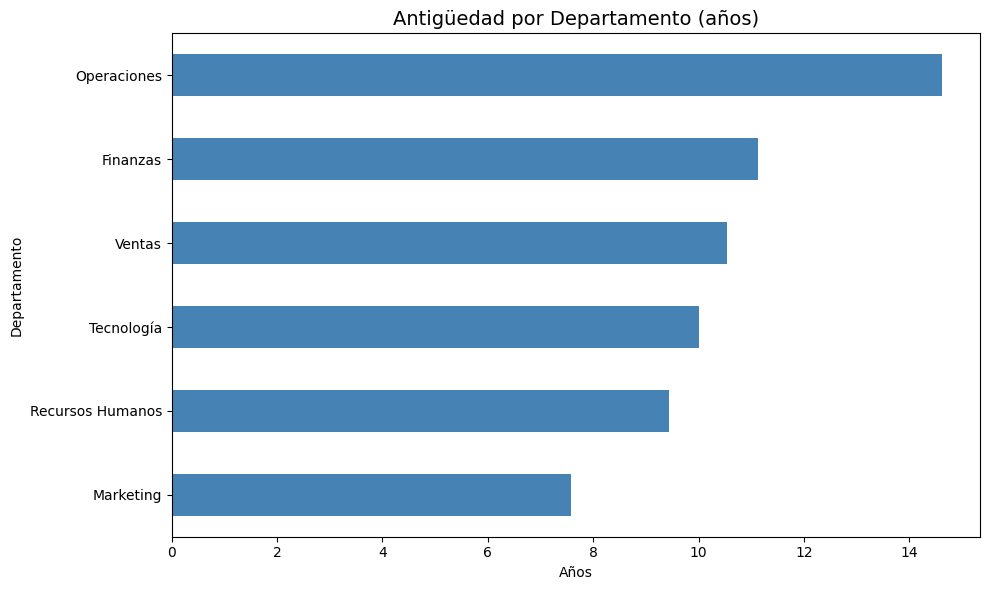

In [ ]:
plt.figure(figsize=(10,6))
anti_departamento.sort_values().plot(kind='barh', color='steelblue')
plt.title('Antigüedad por Departamento (años)', fontsize=14)
plt.xlabel('Años')
plt.ylabel('Departamento')
plt.tight_layout()
plt.show()

**Conclusión:** Operaciones y Finanzas concentran los empleados más antiguos, indicando baja rotación. Recursos Humanos y Marketing tienen mayor renovación, lo que puede reflejar mayor demanda de perfiles nuevos y cambios frecuentes en estas áreas.

##Análisis 5 - Desempeño por Departamento
¿Qué áreas concentran el mejor desempeño?

In [ ]:
desemp_departamento = df.groupby(['departamento','desempeno'])['empleado_id'].count().unstack().fillna(0)
desemp_departamento

desempeno,Bueno,Excelente,Regular
departamento,,,
Finanzas,9.0,6.0,2.0
Marketing,9.0,3.0,2.0
Operaciones,8.0,5.0,5.0
Recursos Humanos,7.0,3.0,4.0
Tecnología,5.0,15.0,0.0
Ventas,8.0,5.0,4.0


<Figure size 1000x600 with 0 Axes>

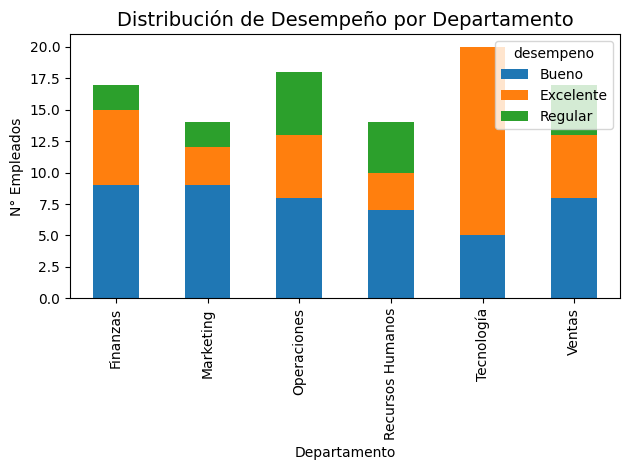

In [ ]:
plt.figure(figsize=(10,6))
desemp_departamento.plot(kind='bar', stacked=True)
plt.title('Distribución de Desempeño por Departamento', fontsize=14)
plt.xlabel('Departamento')
plt.ylabel('N° Empleados')
plt.tight_layout()
plt.show()

**Conclusión:** Tecnología no registra desempeño Regular — sus empleados son Buenos o Excelentes. Operaciones registra la mayor proporción de desempeño Regular. Sería recomendable revisar si los criterios de evaluación reflejan adecuadamente las particularidades de los roles operativos.

## Conclusión General

El análisis revela que Tecnología es el área más valorada
económicamente, con altos salarios y alto desempeño. La empresa
muestra equidad de género a nivel global pero con brechas por área.
La educación y la antigüedad se correlacionan positivamente con el
salario, siendo el posgrado el factor diferenciador más significativo.